In [243]:
#Load Data

In [244]:
import pandas as pd

In [245]:
fraud_df = pd.read_csv("Fraud_Data.csv")
ip_df = pd.read_csv("IpAddress_to_Country.csv")

In [246]:
# Inspect dataset structure, sample records, and basic statistics

In [247]:
print(ip_df.head())
print()
fraud_df.head()

   lower_bound_ip_address  upper_bound_ip_address    country
0              16777216.0                16777471  Australia
1              16777472.0                16777727      China
2              16777728.0                16778239      China
3              16778240.0                16779263  Australia
4              16779264.0                16781311      China



,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [248]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


In [249]:
ip_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 138846 entries, 0 to 138845
Data columns (total 3 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   lower_bound_ip_address  138846 non-null  float64
 1   upper_bound_ip_address  138846 non-null  int64  
 2   country                 138846 non-null  str    
dtypes: float64(1), int64(1), str(1)
memory usage: 3.2 MB


In [250]:
fraud_df[["age","purchase_value"]].describe()


,age,purchase_value
count,151112.000000,151112.000000
mean,33.140704,36.935372
std,8.617733,18.322762
min,18.000000,9.000000
25%,27.000000,22.000000
50%,33.000000,35.000000
75%,39.000000,49.000000
max,76.000000,154.000000


In [251]:
#Data Cleaning

In [252]:
# Convert signup and purchase timestamps to datetime format
fraud_df["signup_time"]=pd.to_datetime(fraud_df["signup_time"])
fraud_df["purchase_time"]=pd.to_datetime(fraud_df["purchase_time"])


In [253]:
# Check for duplicate records in both datasets
int(fraud_df.duplicated().sum())

0

In [254]:
int(ip_df.duplicated().sum())

0

In [255]:
# Check missing values to understand data quality issues
fraud_df.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [256]:
ip_df.isna().sum()

lower_bound_ip_address    0
upper_bound_ip_address    0
country                   0
dtype: int64

In [257]:
## Detect outliers using the IQR method

In [258]:
def check_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(col)
    print("Count:", len(outliers))
    print("Percentage:", f"{len(outliers)/len(df)*100:.2f}%")

    if len(outliers) > 0:
        print("Max:", outliers[col].max())
        print("Min:", outliers[col].min())

check_outliers(fraud_df, "purchase_value")
print("-------------------------------")
check_outliers(fraud_df, "age")

purchase_value
Count: 1067
Percentage: 0.71%
Max: 154
Min: 90
-------------------------------
age
Count: 776
Percentage: 0.51%
Max: 76
Min: 58


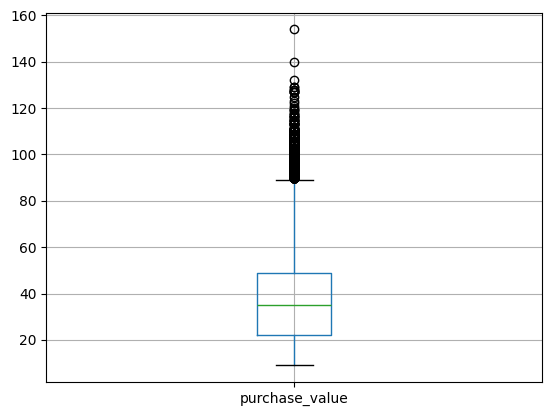

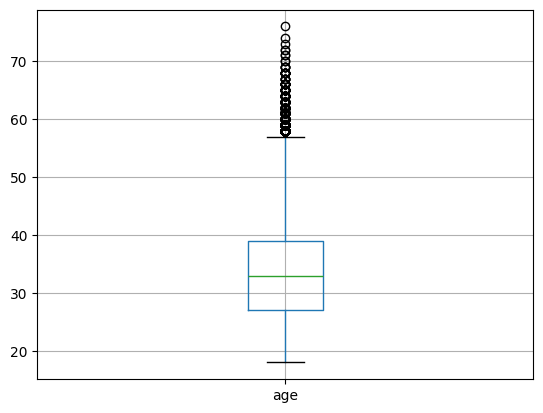

In [259]:
import matplotlib.pyplot as plt

fraud_df.boxplot(column="purchase_value")
plt.show()

fraud_df.boxplot(column="age")
plt.show()


In [260]:
#Feature Engineering

In [261]:
# Create age groups to simplify age-based fraud analysis
import numpy as np
bins=[18,25,35,50,100]
group_names=["18-25","26-35","36-50","50+"]
fraud_df["age_binned"]=pd.cut(
    fraud_df["age"],
    bins=bins,
    labels=group_names,
    include_lowest=True
    


)

fraud_df[["age", "age_binned"]].head(5)

,age,age_binned
0,39,36-50
1,53,50+
2,53,50+
3,41,36-50
4,45,36-50


In [262]:
# Extract time-based features from signup and purchase timestamps

In [263]:
fraud_df["signup_hour"]=fraud_df["signup_time"].dt.hour
fraud_df["signup_hour"].head()

0    22
1    20
2    18
3    21
4     7
Name: signup_hour, dtype: int32

In [264]:
fraud_df["signup_day"]=fraud_df["signup_time"].dt.day
fraud_df["signup_day"].head()

0    24
1     7
2     1
3    28
4    21
Name: signup_day, dtype: int32

In [265]:
fraud_df["purchase_hour"]=fraud_df["purchase_time"].dt.hour
fraud_df["purchase_hour"].head()

0     2
1     1
2    18
3    13
4    18
Name: purchase_hour, dtype: int32

In [266]:
fraud_df["purchase_day"]=fraud_df["purchase_time"].dt.day
fraud_df["purchase_day"].head()


0    18
1     8
2     1
3     4
4     9
Name: purchase_day, dtype: int32

In [267]:
fraud_df["purchase_month"]=fraud_df["purchase_time"].dt.month
fraud_df["purchase_month"].head()

0    4
1    6
2    1
3    5
4    9
Name: purchase_month, dtype: int32

In [268]:
# Calculate the time difference between signup and purchase
fraud_df["diff_time"]= fraud_df["purchase_time"] -fraud_df["signup_time"]
fraud_df["diff_time"].sort_values(ascending=False).head(10)

25333    119 days 23:59:32
95073    119 days 23:58:59
145612   119 days 23:56:55
73700    119 days 23:55:59
141752   119 days 23:54:40
59252    119 days 23:52:57
18326    119 days 23:52:42
107378   119 days 23:52:24
91739    119 days 23:52:05
40562    119 days 23:49:09
Name: diff_time, dtype: timedelta64[us]

In [269]:
# Convert time difference into hours and days for easier analysis

In [270]:
fraud_df["diff_day"] = fraud_df["diff_time"].dt.total_seconds() / 86400

fraud_df["diff_day"].sort_values(ascending=False).head(10)

25333     119.999676
95073     119.999294
145612    119.997859
73700     119.997211
141752    119.996296
59252     119.995104
18326     119.994931
107378    119.994722
91739     119.994502
40562     119.992465
Name: diff_day, dtype: float64

In [271]:
fraud_df["diff_hours"] = fraud_df["diff_time"].dt.total_seconds() / 3600

fraud_df["diff_hours"].sort_values(ascending=False).head(10)

25333     2879.992222
95073     2879.983056
145612    2879.948611
73700     2879.933056
141752    2879.911111
59252     2879.882500
18326     2879.878333
107378    2879.873333
91739     2879.868056
40562     2879.819167
Name: diff_hours, dtype: float64

In [272]:
# Categorize users based on how quickly they made a purchase after signup
bins=[0,1,3,6,12,24,72,168,float("inf")]

labels=["<1 h","1-3 h","3-6 h","6-12 h","12-24 h","1-3 d","3-7 d",">7 d"]
fraud_df["time_category"]=pd.cut(
    fraud_df["diff_hours"],
    bins=bins,
    labels=labels,
    include_lowest=True

)

fraud_df["time_category"].value_counts()

time_category
>7 d       135272
<1 h         7641
3-7 d        4714
1-3 d        2368
12-24 h       579
6-12 h        298
3-6 h         141
1-3 h          99
Name: count, dtype: int64

In [273]:
# Create Daytime/Nighttime feature based on purchase hour
def time_period(hour):
    if 6 <= hour < 18:
        return "Daytime"
    else:
        return "Nighttime"

fraud_df["time_of_day"] = fraud_df["purchase_hour"].apply(time_period)
fraud_df["time_of_day"].head()

0    Nighttime
1    Nighttime
2    Nighttime
3      Daytime
4    Nighttime
Name: time_of_day, dtype: str

In [274]:
# Behavior Analysis

In [275]:
# Analyze overall fraud distribution
print(fraud_df["class"].value_counts())
fraud_df["class"].value_counts(normalize=True)

class
0    136961
1     14151
Name: count, dtype: int64


class
0    0.906354
1    0.093646
Name: proportion, dtype: float64

In [276]:
#Univariate Analysis

In [277]:
# Compare purchase value across fraud and non-fraud transactions

In [278]:
fraud_df.groupby(["class","age_binned"])["purchase_value"].mean()

class  age_binned
0      18-25         36.959450
       26-35         36.861224
       36-50         36.994235
       50+           36.924068
1      18-25         37.597125
       26-35         36.398253
       36-50         37.274805
       50+           37.720339
Name: purchase_value, dtype: float64

In [279]:

fraud_df.groupby(["class","source"])["purchase_value"].mean()

class  source
0      Ads       36.947414
       Direct    36.902483
       SEO       36.925058
1      Ads       36.708870
       Direct    37.263484
       SEO       37.121212
Name: purchase_value, dtype: float64

In [280]:
fraud_df.groupby(["class","browser"])["purchase_value"].mean()

class  browser
0      Chrome     36.998447
       FireFox    36.911757
       IE         36.756619
       Opera      36.599462
       Safari     37.084128
1      Chrome     37.335805
       FireFox    36.225875
       IE         37.431440
       Opera      36.067073
       Safari     36.373933
Name: purchase_value, dtype: float64

In [281]:
fraud_df.groupby(["class","sex"])["purchase_value"].mean()


class  sex
0      F      36.926097
       M      36.931792
1      F      36.551688
       M      37.292151
Name: purchase_value, dtype: float64

In [282]:
# Analyze fraud rate by browser, source, sex, and age group

In [283]:
pd.crosstab(fraud_df["browser"], fraud_df["class"], normalize="index").sort_values(by=1, ascending=False)


class,0,1
browser,,
Chrome,0.901208,0.098792
FireFox,0.904835,0.095165
Safari,0.909799,0.090201
Opera,0.910773,0.089227
IE,0.913225,0.086775


In [284]:
pd.crosstab(fraud_df["sex"], fraud_df["class"],normalize="index").sort_values(by=1,ascending=False)

class,0,1
sex,,
M,0.904477,0.095523
F,0.908993,0.091007


In [285]:
pd.crosstab(fraud_df["age_binned"], fraud_df["class"],normalize="index").sort_values(by=1,ascending=False)

class,0,1
age_binned,,
50+,0.900401,0.099599
36-50,0.904047,0.095953
26-35,0.907071,0.092929
18-25,0.909624,0.090376


In [286]:
pd.crosstab(fraud_df["source"], fraud_df["class"],normalize="index" ).sort_values(by=1,ascending=False)

class,0,1
source,,
Direct,0.894630,0.105370
Ads,0.907934,0.092066
SEO,0.910715,0.089285


In [287]:

pd.crosstab(
    fraud_df["time_category"],
    fraud_df["class"],
    normalize="index"
).sort_values(by=1, ascending=False)

class,0,1
time_category,,
<1 h,0.004842,0.995158
3-6 h,0.950355,0.049645
3-7 d,0.953118,0.046882
>7 d,0.954263,0.045737
12-24 h,0.955095,0.044905
1-3 d,0.959882,0.040118
6-12 h,0.966443,0.033557
1-3 h,0.989899,0.010101


In [288]:
# fraud vs time diff
fraud_df.groupby("class")["diff_hours"].agg(["mean","count"])

,mean,count
class,,
0,1441.994052,136961
1,673.289542,14151


In [289]:
pd.crosstab(
    [fraud_df["time_category"], fraud_df["time_of_day"]],
    fraud_df["class"],
    normalize="index"
)

class                             0         1
time_category time_of_day                    
<1 h          Daytime      0.004146  0.995854
              Nighttime    0.005648  0.994352
1-3 h         Daytime      1.000000  0.000000
              Nighttime    0.979167  0.020833
3-6 h         Daytime      0.922078  0.077922
              Nighttime    0.984375  0.015625
6-12 h        Daytime      0.948052  0.051948
              Nighttime    0.986111  0.013889
12-24 h       Daytime      0.950658  0.049342
              Nighttime    0.960000  0.040000
1-3 d         Daytime      0.959356  0.040644
              Nighttime    0.960404  0.039596
3-7 d         Daytime      0.948063  0.051937
              Nighttime    0.958140  0.041860
>7 d          Daytime      0.954479  0.045521
              Nighttime    0.954045  0.045955

In [290]:
#Combination Analysis

In [291]:

source_browser_time_analysis=fraud_df.groupby(["source","browser","time_category"]).agg(fraud_rate=("class","mean"),count=("class","count")).reset_index()

source_browser_time_analysis.sort_values(by="fraud_rate", ascending=False).head()

,source,browser,time_category,fraud_rate,count
24,Ads,Opera,<1 h,1.000000,43
102,SEO,Opera,<1 h,1.000000,83
110,SEO,Safari,<1 h,1.000000,504
55,Direct,IE,<1 h,0.997423,388
86,SEO,FireFox,<1 h,0.996711,608


In [292]:

demographic_time_analysis=fraud_df.groupby(["sex","age_binned","time_category"]).agg(fraud_rate=("class","mean"),count=("class","count")).reset_index()

demographic_time_analysis.sort_values(by="fraud_rate", ascending=False).head()

,sex,age_binned,time_category,fraud_rate,count
32,M,18-25,<1 h,1.000000,859
0,F,18-25,<1 h,0.996683,603
8,F,26-35,<1 h,0.995388,1301
16,F,36-50,<1 h,0.995155,1032
48,M,36-50,<1 h,0.994755,1716


In [293]:
#Country Analysis

In [294]:
# Sort datasets before performing range-based IP matching
fraud_df = fraud_df.sort_values("ip_address")
ip_df = ip_df.sort_values("lower_bound_ip_address")

In [295]:
# Match each IP address to its country using range-based merge
# Use merge_asof to match each transaction IP with the closest lower IP range,
# then validate that the IP is still within the upper bound.
merged = pd.merge_asof(
    fraud_df,
    ip_df,
    left_on="ip_address",
    right_on="lower_bound_ip_address",
    direction="backward"
)

In [296]:
merged = merged[
    merged["ip_address"] <= merged["upper_bound_ip_address"]
]

merged.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,...,purchase_day,purchase_month,diff_time,diff_day,diff_hours,time_category,time_of_day,lower_bound_ip_address,upper_bound_ip_address,country
634,247547,2015-06-28 03:00:34,2015-08-09 03:57:29,47,KIXYSVCHIPQBR,SEO,Safari,F,30,1.677886e+07,...,9,8,42 days 00:56:55,42.039525,1008.948611,>7 d,Nighttime,16778240.0,16779263.0,Australia
635,220737,2015-01-28 14:21:11,2015-02-11 20:28:28,15,PKYOWQKWGJNJI,SEO,Chrome,F,34,1.684205e+07,...,11,2,14 days 06:07:17,14.255058,342.121389,>7 d,Nighttime,16809984.0,16842751.0,Thailand
636,390400,2015-03-19 20:49:09,2015-04-11 23:41:23,44,LVCSXLISZHVUO,Ads,IE,M,29,1.684366e+07,...,11,4,23 days 02:52:14,23.119606,554.870556,>7 d,Nighttime,16843264.0,16843775.0,China
637,69592,2015-02-24 06:11:57,2015-05-23 16:40:14,55,UHAUHNXXUADJE,Direct,Chrome,F,30,1.693873e+07,...,23,5,88 days 10:28:17,88.436308,2122.471389,>7 d,Daytime,16924672.0,16941055.0,China
638,174987,2015-07-07 12:58:11,2015-11-03 04:04:30,51,XPGPMOHIDRMGE,SEO,Chrome,F,37,1.697198e+07,...,3,11,118 days 15:06:19,118.629387,2847.105278,>7 d,Nighttime,16941056.0,16973823.0,Thailand


In [297]:
merged["country"].value_counts(normalize=True).head()

country
United States        0.449484
China                0.093212
Japan                0.056572
United Kingdom       0.034767
Korea Republic of    0.032227
Name: proportion, dtype: float64

In [298]:
# country time fraud rate
purchase_by_group = merged.groupby(
    ["class","country","time_category"]
)["purchase_value"].agg(["mean","count"]).reset_index()
# filter low counts
purchase_by_group = purchase_by_group[purchase_by_group["count"] > 100]
# top fraud countries

purchase_by_group.sort_values(by=["mean","count"], ascending=[False, False]).head(10)

,class,country,time_category,mean,count
632,1,India,<1 h,43.923810,105
681,1,Mexico,<1 h,43.485149,101
661,1,Korea Republic of,<1 h,42.203883,206
567,1,Brazil,<1 h,40.692810,153
613,1,France,>7 d,40.544643,112
328,0,Morocco,>7 d,40.088435,147
620,1,Germany,>7 d,40.027778,144
572,1,Canada,<1 h,40.023041,217
348,0,New Zealand,>7 d,39.212560,207
98,0,China,1-3 d,39.009346,214


In [299]:
# purchase behavior analysis
fraud_by_country_time = merged.groupby(
    ["country", "time_category"]
).agg(
    fraud_rate=("class", "mean"),
    count=("class", "count"),
    avg_purchase=("purchase_value", "mean")
).reset_index()
# filter low counts
fraud_by_country_time = fraud_by_country_time[fraud_by_country_time["count"] > 100]

fraud_by_country_time.sort_values(by=["fraud_rate","count"], ascending=[False, False]).head(10)

,country,time_category,fraud_rate,count,avg_purchase
559,United Kingdom,<1 h,1.000000,269,36.609665
340,Mexico,<1 h,1.000000,101,43.485149
272,Japan,<1 h,0.995122,410,34.324390
567,United States,<1 h,0.994995,2997,37.630297
180,France,<1 h,0.994536,183,32.289617
62,Brazil,<1 h,0.993506,154,40.584416
193,Germany,<1 h,0.990991,111,31.864865
232,India,<1 h,0.990566,106,44.113208
289,Korea Republic of,<1 h,0.990385,208,42.057692
100,China,<1 h,0.990310,516,36.472868


In [300]:
import matplotlib.pyplot as plt
import seaborn as sns


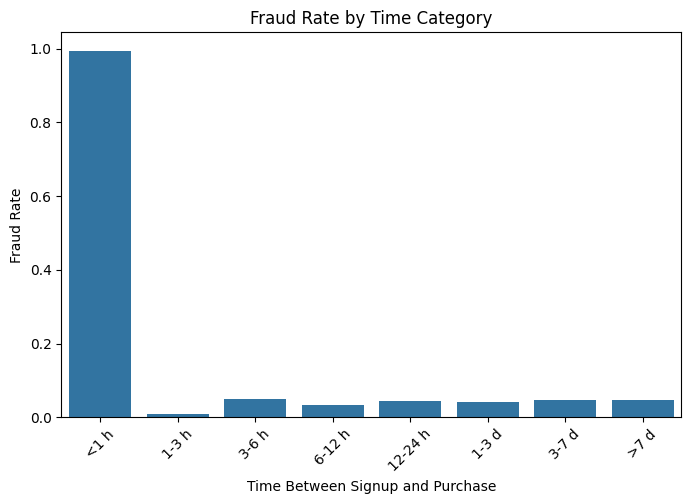

In [301]:
time_fraud = fraud_df.groupby("time_category")["class"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=time_fraud, x="time_category", y="class")
plt.title("Fraud Rate by Time Category")
plt.xlabel("Time Between Signup and Purchase")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.show()

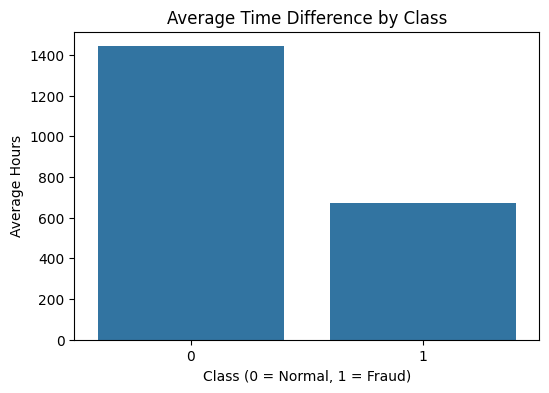

In [302]:
avg_time = fraud_df.groupby("class")["diff_hours"].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=avg_time, x="class", y="diff_hours")
plt.title("Average Time Difference by Class")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Average Hours")
plt.show()

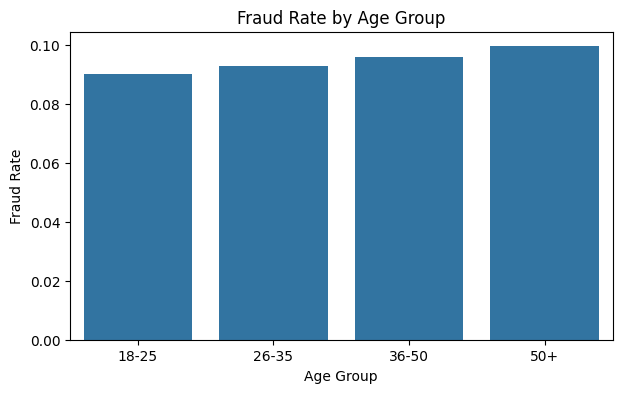

In [323]:
age_fraud = fraud_df.groupby("age_binned")["class"].mean().reset_index(name="fraud_rate")



plt.figure(figsize=(7,4))
sns.barplot(data=age_fraud, x="age_binned", y="fraud_rate")
plt.title("Fraud Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Fraud Rate")
plt.show()

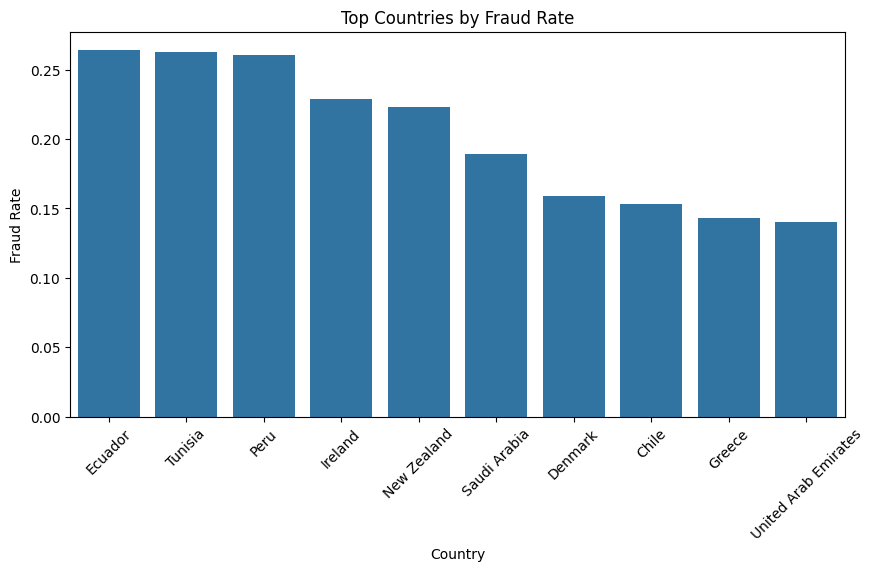

In [325]:
country_fraud = merged.groupby("country").agg(
    fraud_rate=("class","mean"),
    count=("class","count")
).reset_index()

country_fraud = country_fraud[country_fraud["count"] > 100]
country_fraud = country_fraud.sort_values(by="fraud_rate", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=country_fraud, x="country", y="fraud_rate")
plt.title("Top Countries by Fraud Rate")
plt.xlabel("Country")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.show()

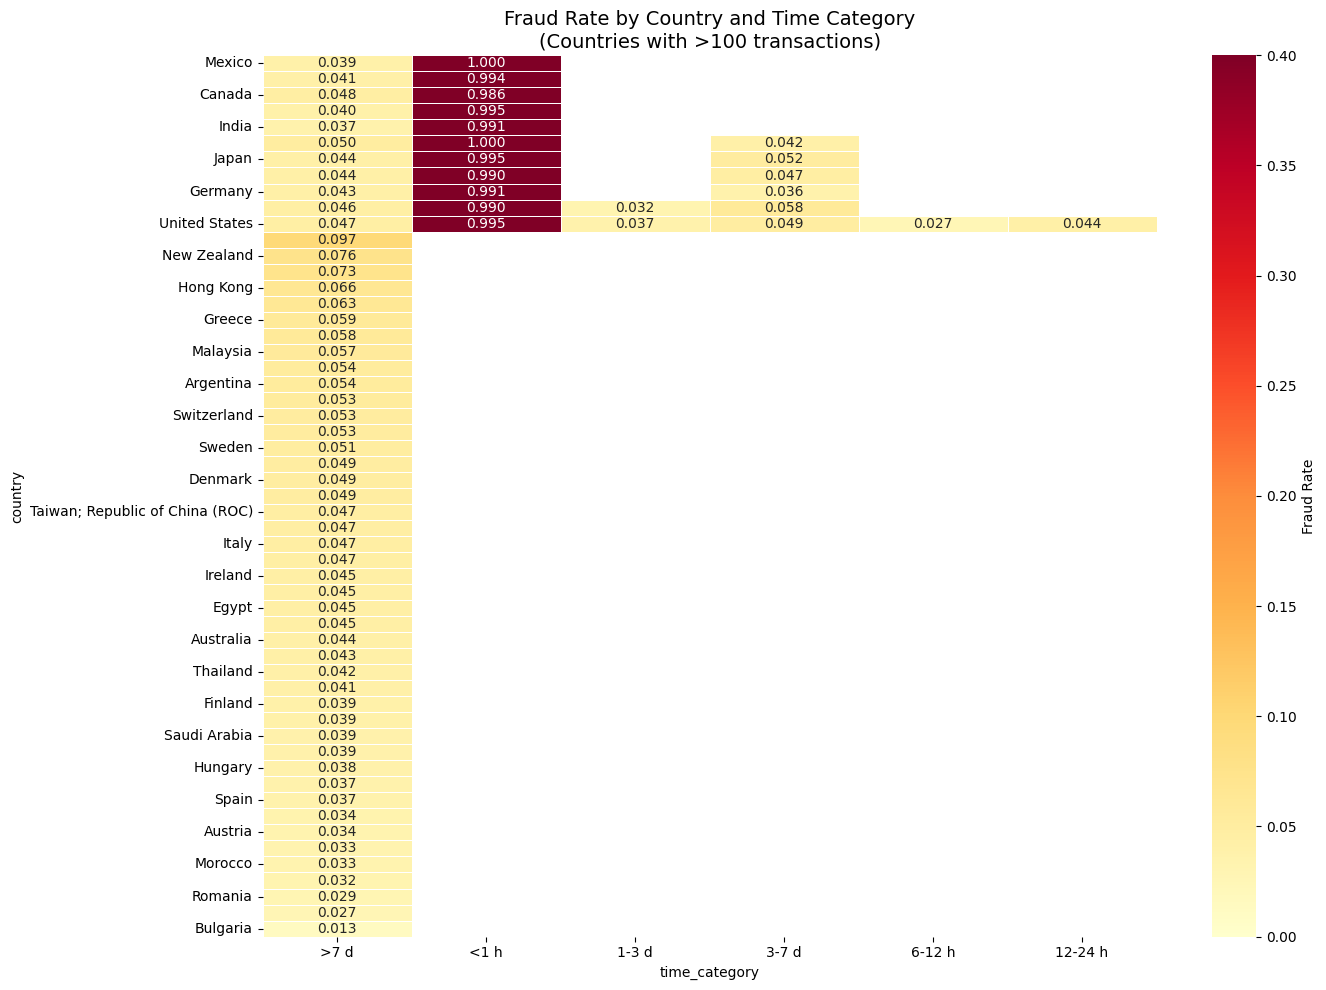

In [307]:
# Heatmap محسنة
pivot = fraud_by_country_time.pivot(index="country", columns="time_category", values="fraud_rate")

# نأخذ فقط الدول اللي عندها بيانات كافية
min_transactions = 100
valid_countries = merged['country'].value_counts()[merged['country'].value_counts() > min_transactions].index
pivot = pivot.loc[pivot.index.isin(valid_countries)]

# نرتب حسب متوسط الـ fraud rate
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(14, 10))
sns.heatmap(pivot, 
            cmap="YlOrRd", 
            annot=True, 
            fmt=".3f",
            linewidths=0.5,
            cbar_kws={'label': 'Fraud Rate'},
            vmin=0, 
            vmax=0.4)   # مهم: حدد vmax حسب البيانات

plt.title("Fraud Rate by Country and Time Category\n(Countries with >100 transactions)", fontsize=14)
plt.tight_layout()
plt.show()

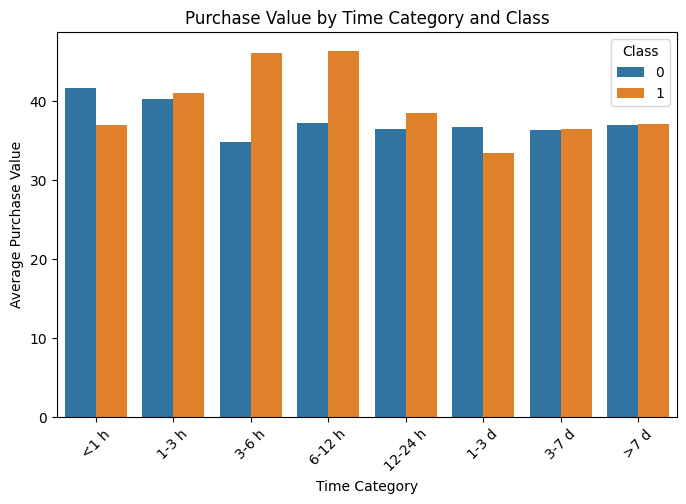

In [ ]:
pv_time_class = fraud_df.groupby(["time_category","class"])["purchase_value"].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(data=pv_time_class, x="time_category", y="purchase_value", hue="class")
plt.title("Purchase Value by Time Category and Class")
plt.xlabel("Time Category")
plt.ylabel("Average Purchase Value")
plt.xticks(rotation=45)
plt.legend(title="Class")
plt.show()

In [ ]:
# Fraud Detection Analysis – Key Insights

## 1. Primary Finding
"""
The most significant indicator of fraud is the time between account signup and first purchase.  
Transactions completed within the first hour after signup show a dramatically higher fraud rate.  
As the time interval increases, the probability of fraud decreases substantially."""

## 2. Purchase Value
"""There is no meaningful relationship between purchase value and fraud.  
Fraudulent transactions closely resemble normal transactions in terms of spending behavior.  
This indicates that fraudsters intentionally mimic legitimate users, making this feature weak for prediction."""

## 3. Geographic Patterns
"""Fraud rates vary across countries.  
However, country alone is not a strong indicator.  

The highest risk emerges when combining:
Country + Fast Transaction (<1 hour)

This combination identifies the most critical fraud segments."""

## 4. Behavioral Patterns
"""Fraud in this dataset is primarily behavior-driven rather than attribute-driven.

- Transaction speed is the dominant signal  
- Demographics (age, gender) have limited impact  
- Browser and traffic source show only minor differences  """

## Executive Summary

"""The dominant fraud pattern is:

Account signup followed by an immediate purchase (within 1 hour).

Time-based features are the strongest predictors of fraud, significantly outperforming all other variables.  
In contrast, purchase value and user attributes provide minimal discriminatory power.
"""
## Recommendations
"""
- Implement real-time monitoring for transactions occurring within the first hour  
- Add verification steps (e.g., OTP, 2FA) for fast purchases  
- Prioritize high-risk country + fast transaction combinations  
- Avoid relying on weak signals such as purchase value alone  """